# HBI&nbsp;02 — the forward-response kernel (the deconvolution engine)

**Where we are.** NB0 set up the estimand (a population $f(N,z)$ measured from a
*catalog* of imperfect detections). NB1 showed the whole machine close on a
*synthetic* catalog: inject a known $f(N)$, forward-simulate detections, run the
real MAP deconvolution, recover the truth. The one thing NB1 hand-built was the
**forward kernel** — the object that maps true columns $N$ to measured columns
$\hat x$. This notebook opens up the *real* kernel, measured on the 2LPT-0 mock,
and **builds it up one step at a time, each step with a figure**, so you can see
exactly how the forward response is constructed before it is assembled.

**What the kernel is.** Every DLA the GP reports carries a measured
$\hat x=\log_{10}\hat N_{\rm HI}$ that differs from the absorber's true $N$ by a
noisy, *biased* amount. The kernel is the conditional density of that error:

$$ p(\hat x \mid N,\,\mathrm{SNR},\,z) $$

— the **forward response**. It is what the estimator *deconvolves*: given the
catalog of $\hat x_i$, undo the smear+bias to recover the true $f(N)$.

**Why this is the crux.** There are two superficially similar objects, and using
the wrong one silently double-counts the population:

| object | reads as | normalised over | role |
|---|---|---|---|
| **forward** $p(\hat x\mid N)$ | "given the truth $N$, where does $\hat x$ land" | $\hat x$ (so $\int p\,d\hat x=1$) | the **likelihood** — what we deconvolve |
| **GP posterior** $\kappa(N\mid\hat x)$ | "given the measurement $\hat x$, where was $N$" | $N$ (so $\int\kappa\,d\log N=1$) | a *per-spectrum* belief, already prior-folded |

**Roadmap of this notebook.**

1. The crux — *forward* vs *posterior*, and the Bayes flip.
2. Load the two real 2LPT-0 fixtures (parametric surfaces + non-parametric density).
3. **Build the forward response step by step** — six figures:
   * **Step 1** — what we measure: the residual $\Delta=\hat x-x_{\rm true}$, rising ($\Delta>0$).
   * **Step 2** — the bias surface $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$.
   * **Step 3** — the scatter surface $\sigma(\hat x,z)$ (the response *width*).
   * **Step 4** — the per-cell columns: $p(\hat x\mid N)$ at fixed true-$N$ anchors.
   * **Step 5** — assemble the forward response *matrix* $p(\hat x\mid N)$.
   * **Step 6** — the forward normalisation signature ($\int p\,d\hat x=1$ at every true $N$; the over-$N$ contraction is N-dependent, shown illustratively).
4. The assembled four-panel kernel figure (the canonical summary).
5. How a design-tensor entry $A_{i,jN,kz}$ is built from this kernel.
6. Honesty note — which response the estimator actually uses.

> **Mock only (2LPT-0).** No real-survey (LOA) values appear here. Every printed
> number is computed by the code in the cell — nothing is typed in.

> Companion notebooks: **NB0** motivation & estimand · **NB1** synthetic
> closure · **NB3** likelihood + MAP solve + MC band *using this kernel*.

---

📄 **Paper-draft correspondence**: this notebook ↔ **Method** §*Forward (N,z) response kernel A* (Eqs. A_ib, P^z, b_eff); **Validation** §(2) *Forward-response kernel characterisation* (Fig. kernel).


In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
import sys
from pathlib import Path
_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
              if (p / "CDDF_analysis" / "hbi" / "cddf_catalog_hbi.py").exists()), None)
assert _root is not None, "repo root not found"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
DATA = _root / "CDDF_analysis" / "hbi" / "tutorial_data"
import numpy as np
from CDDF_analysis.hbi import cddf_catalog_hbi as H
from CDDF_analysis.hbi.znz_kernel import ZNZModel, EmpiricalForwardDensity
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
print("env ready | numpy", np.__version__, "| fixtures:", DATA.is_dir())

env ready | numpy 2.4.4 | fixtures: True


In [2]:
# numpy 2.x renamed trapz -> trapezoid (this env is numpy 2.x); alias both.
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
# colour palette + z slices reused across the step figures
Z_SLICES = [2.25, 2.75, 3.25]
Z_COLS   = ["#9467bd", "#d62728", "#ff7f0e"]
print("helpers ready | z slices:", Z_SLICES)

helpers ready | z slices: [2.25, 2.75, 3.25]


## The crux: deconvolve the *forward* response, not the GP *posterior*

The likelihood the estimator needs answers a forward question — *given a true
column $N$ at this SNR and redshift, where does the GP's reported $\hat x$ land?*
That density,

$$ p(\hat x \mid N,\,\mathrm{SNR},\,z), \qquad \int p(\hat x\mid N)\,d\hat x = 1, $$

is normalised **over $\hat x$** at fixed $N$. Crucially $\int p(\hat x\mid N)\,d(\log N)\neq1$
— the forward map does *not* integrate to one across true columns.

The GP, by contrast, hands you a **posterior** for each spectrum:

$$ \kappa(N \mid \hat x), \qquad \int \kappa(N\mid\hat x)\,d(\log N) = 1, $$

normalised **over $N$** at fixed $\hat x$. By Bayes these are related through the
population prior, $\kappa(N\mid\hat x)\propto p(\hat x\mid N)\,f(N)$ — but they are
**not interchangeable**. Contracting the catalog with $\kappa$ instead of $p$ is a
*category error*: $\kappa$ already has the population folded in (through $f(N)$),
so summing it over the catalog double-counts the population you are trying to
measure. The forward map $p$ is prior-free in $N$; that is exactly why it can be
deconvolved.

**The "Bayes flip" — why the posterior *looks* fine but cannot deconvolve.**
Near the prior edge at $\log N_{\rm HI}\approx 20.3$ the forward response is
strongly **up-migrating**: a true sub-DLA scatters *up* into the DLA range more
often than a true DLA scatters down (Eddington bias against a steep $f(N)$). So
$p(\hat x\mid N)$ has a real, $\hat x$-rising conditional bias. Yet the GP
*posterior* $\kappa(N\mid\hat x)$ shows almost **no** conditional shift ($|\text{mean shift}|\le 0.033$ dex) — because
the up-migrating forward smear is **balanced** by the steep falling $f(N)$ prior
that multiplies it. The two effects cancel in the posterior. That cancellation
is comforting if you only look at $\kappa$ (it "looks unbiased"), but it is
precisely why $\kappa$ **cannot** remove the over-recovery: the bias is hidden
inside the prior it carries. Only the *forward* response, which keeps the
up-migration explicit and prior-free, can be inverted to re-steepen the high-$N$
tail and fix $\Omega_{\rm HI}$.

Everything below builds *that* forward response — step by step.

## Load the real 2LPT-0 forward kernel

Two committed fixtures reconstruct the production dataclasses:

* `znz_2lpt0.npz` → **`ZNZModel`**: the fitted *parametric* forward surfaces —
  the conditional bias $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$ and the
  conditional scatter $\sigma(\hat x,z)$ (both 2-D polynomials, centred at a
  reference point for numerical stability).
* `forward_response_2lpt0.npz` → **`EmpiricalForwardDensity`**: the genuine
  *non-parametric* forward density $p(\hat x\mid N,\mathrm{SNR},z)$ — a smoothed
  truth-match residual histogram per $(\mathrm{SNR},z)$ cell, evaluated at several
  true-$N$ anchors. This is the headline `resp_family="empirical"` kernel.

Both are pure mock products (no real-survey input). The `ZNZModel` gives the
*parametric* view (Steps 2–3); the `EmpiricalForwardDensity` gives the
*non-parametric* view (Steps 1, 4–6).

In [3]:
# --- ZNZModel: parametric bias / scatter surfaces ----------------------------
z = np.load(DATA / "znz_2lpt0.npz", allow_pickle=True)
znz = ZNZModel(
    b_coef=z["b_coef"], sig_coef=z["sig_coef"],
    xhat_ref=float(z["xhat_ref"]), z_ref=float(z["z_ref"]),
    b_ref=float(z["b_ref"]), sig_ref=float(z["sig_ref"]),
    z_covariate=str(z["z_covariate"]),
    deg_xhat=int(z["deg_xhat"]), deg_z=int(z["deg_z"]),
)

# --- EmpiricalForwardDensity: non-parametric p(x̂|N,SNR,z) -------------------
f = np.load(DATA / "forward_response_2lpt0.npz", allow_pickle=True)
emp = EmpiricalForwardDensity(
    rho=f["emp_rho"], N_anchors=f["emp_N_anchors"], r_grid=f["emp_r_grid"],
    snr_edges=f["emp_snr_edges"], z_edges=f["emp_z_edges"],
)

z_ref = float(znz.z_ref)

print("ZNZModel (parametric forward surfaces)")
print(f"  reference point      : x̂_ref={znz.xhat_ref:.3f}, z_ref={znz.z_ref:.3f}")
print(f"  b_ref (bias @ ref)   : {znz.b_ref:+.4f} dex   (already > 0: up-migration)")
print(f"  sigma_ref (@ ref)    : {znz.sig_ref:.4f} dex")
print(f"  poly degrees (x̂, z)  : ({znz.deg_xhat}, {znz.deg_z})")
print()
print("EmpiricalForwardDensity (non-parametric p(x̂|N,SNR,z))")
print(f"  rho grid shape       : {emp.rho.shape}  (n_snr, n_z, n_anchor, n_r)")
print(f"  SNR cell edges       : {emp.snr_edges}")
print(f"  z   cell edges       : {emp.z_edges}")
print(f"  residual grid r=x̂-N  : [{emp.r_grid[0]:+.2f}, {emp.r_grid[-1]:+.2f}] "
      f"dex, {len(emp.r_grid)} pts")
print(f"  N_true anchors [0,0] : {np.round(emp.N_anchors[0,0], 3)}")

ZNZModel (parametric forward surfaces)
  reference point      : x̂_ref=20.055, z_ref=2.480
  b_ref (bias @ ref)   : +0.0855 dex   (already > 0: up-migration)
  sigma_ref (@ ref)    : 0.1435 dex
  poly degrees (x̂, z)  : (1, 2)

EmpiricalForwardDensity (non-parametric p(x̂|N,SNR,z))
  rho grid shape       : (3, 3, 7, 121)  (n_snr, n_z, n_anchor, n_r)
  SNR cell edges       : [2.  3.5 6.5 inf]
  z   cell edges       : [0.   2.56 2.96  inf]
  residual grid r=x̂-N  : [-1.50, +1.50] dex, 121 pts
  N_true anchors [0,0] : [19.503 19.875 20.093 20.297 20.511 20.767 21.216]


In [4]:
# --- population-representative (SNR, z) cell centres --------------------------
# Each (SNR,z) cell is evaluated at its centre; figures equal-weight-average over
# all populated cells. (Same construction as scripts/plot_kernel.py main().)
def _cell_centres(emp):
    snr_cen = []
    for a in range(len(emp.snr_edges) - 1):
        lo, hi = emp.snr_edges[a], emp.snr_edges[a + 1]
        snr_cen.append(0.5 * (lo + hi) if np.isfinite(hi) else lo * 1.5)
    z_cen = []
    for a in range(len(emp.z_edges) - 1):
        lo, hi = emp.z_edges[a], emp.z_edges[a + 1]
        z_cen.append(0.5 * (lo + hi) if np.isfinite(hi) and lo > 0
                     else (2.2 if lo == 0 else lo * 1.05))
    return snr_cen, z_cen

SNR_CEN, Z_CEN = _cell_centres(emp)
print("SNR cell centres:", [round(s, 2) for s in SNR_CEN])
print("z   cell centres:", [round(z, 2) for z in Z_CEN])

SNR cell centres: [np.float64(2.75), np.float64(5.0), np.float64(9.75)]
z   cell centres: [2.2, np.float64(2.76), np.float64(3.11)]


---
## Building the forward response, step by step

We now construct $p(\hat x\mid N,\mathrm{SNR},z)$ from the ground up. Each step
below is a short explanation followed by a figure. By Step 5 we will have the full
response *matrix* the HBI deconvolves; Step 6 verifies its forward normalisation
signature ($\int p\,d\hat x=1$ at every true $N$).

### Step 1 — what we measure: the residual $\Delta=\hat x-x_{\rm true}$

The raw ingredient is the **truth-match residual**. On every true-positive match
(a GP detection paired with the absorber that actually produced it) we record

$$ \Delta \;=\; \hat x - x_{\rm true} \;=\; \log_{10}\hat N_{\rm HI} - \log_{10} N_{\rm HI}^{\rm true}. $$

If the GP were unbiased, $\Delta$ would scatter symmetrically about $0$. It does
**not**: $\langle\Delta\mid N\rangle>0$ everywhere, and it *rises* steeply toward
the sub-DLA end — true low-$N$ absorbers are systematically **over-reported**.
This is the Eddington **up-migration** at the prior edge.

The committed fixture stores the *smoothed* residual density per true-$N$ anchor
(not the raw scatter points), so the figure below is the population-representative
conditional density $\rho(\Delta\mid N)$ — the equal-weight average of the
empirical residual densities over all populated $(\mathrm{SNR},z)$ cells. The red
curve is the **measured** conditional mean $\langle\Delta\mid N\rangle$ read off
that density; it sits entirely **above zero** (the dotted line) and spikes at the
sub-DLA end ($N_{\rm true}\approx19.5$). This positive, $N$-dependent residual is
what the parametric bias surface $b(\hat x,z)$ (Step 2) fits — though note Step 2
re-expresses it in the *measured*-$\hat x$ frame, where the largest residual lands
at *high* $\hat x$, not at the sub-DLA edge (the two conditioning frames place the
peak at opposite ends; see Step 2).

SELF-CHECK PASS: measured <Delta|N> > 0 for ALL N (range +0.0470 .. +0.2777 dex) — up-migration


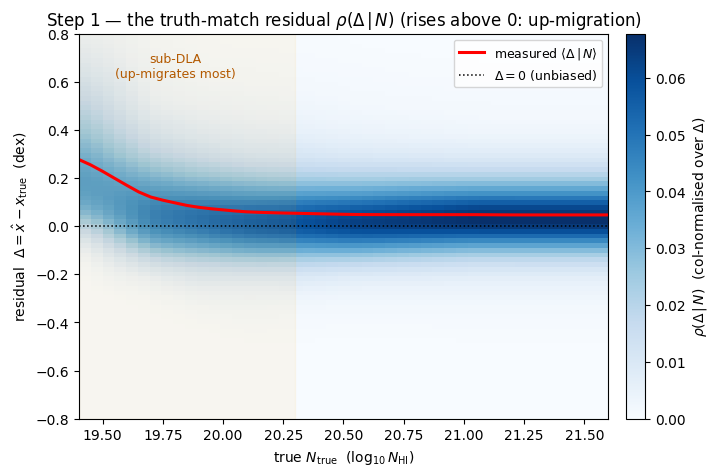

In [5]:
# Step 1: conditional residual density rho(Delta | N), pop-averaged over cells.
N_grid = np.arange(19.4, 21.6 + 1e-9, 0.05)     # true-N axis (anchor-covered range)
d_grid = np.arange(-0.8, 0.8 + 1e-9, 0.02)      # residual Delta = xhat - N_true
Hd = np.zeros((len(d_grid), len(N_grid)))
for sc in SNR_CEN:
    for zc in Z_CEN:
        for j, Nt in enumerate(N_grid):
            # density at xhat = Nt + Delta  ->  rho(Delta | N) on the d_grid
            Hd[:, j] += emp.density(Nt + d_grid, np.full_like(d_grid, Nt), sc, zc)
# column-normalise so each N column is a conditional Delta-density
Hd_n = Hd / np.clip(Hd.sum(0, keepdims=True), 1e-12, None)
d_mean = (Hd_n * d_grid[:, None]).sum(0)         # measured <Delta | N>

# ---- SELF-CHECK: the residual is up-migrating (positive) everywhere ---------
assert np.all(d_mean > 0.0), "residual <Delta|N> not strictly positive"
print(f"SELF-CHECK PASS: measured <Delta|N> > 0 for ALL N "
      f"(range {d_mean.min():+.4f} .. {d_mean.max():+.4f} dex) — up-migration")

fig, ax = plt.subplots(figsize=(7.4, 5.0))
im = ax.imshow(Hd_n, aspect="auto", origin="lower",
               extent=[N_grid[0], N_grid[-1], d_grid[0], d_grid[-1]],
               cmap="Blues")
ax.plot(N_grid, d_mean, "r-", lw=2.2, label=r"measured $\langle\Delta\,|\,N\rangle$")
ax.axhline(0.0, color="k", ls=":", lw=1.1, label=r"$\Delta=0$ (unbiased)")
ax.axvspan(19.4, 20.3, color="orange", alpha=0.06)
ax.text(19.8, 0.62, "sub-DLA\n(up-migrates most)", fontsize=9, ha="center",
        color="#b35900")
ax.set_xlabel(r"true $N_{\rm true}$  ($\log_{10} N_{\rm HI}$)")
ax.set_ylabel(r"residual  $\Delta=\hat x-x_{\rm true}$  (dex)")
ax.set_title(r"Step 1 — the truth-match residual $\rho(\Delta\,|\,N)$ "
             r"(rises above 0: up-migration)")
ax.legend(loc="upper right", fontsize=9)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label(r"$\rho(\Delta\,|\,N)$  (col-normalised over $\Delta$)")
plt.show()

### Step 2 — the bias surface $b(\hat x,z)$

The rising trend from Step 1 is captured by a smooth **parametric** surface:

$$ b(\hat x, z) \;=\; \big\langle\,\hat x - x_{\rm true}\,\big|\,\hat x,\,z\,\big\rangle, $$

a 2-D polynomial of degree `(deg_xhat, deg_z)` in the measured $\hat x$ and the
redshift $z$, centred at a reference point $(\hat x_{\rm ref}, z_{\rm ref})$ for
numerical stability (`ZNZModel._design` builds the `polyvander2d` design matrix;
`fit_znz_model` solves the least-squares fit). Here the fit is **degree 1 in
$\hat x$, degree 2 in $z$**.

Two facts make this the *up-migration* surface:

* $b(\hat x,z) > 0$ — the conditional bias is positive (over-reporting), and
* **$b$ rises *monotonically* toward high $\hat x$** — from $+0.062$ dex at
  $\hat x=19.6$ to $+0.208$ dex at $\hat x=22.4$ (at the $20.3$ edge it is only
  $\sim+0.099$, mid-range, *not* a peak). In the **measured-$\hat x$** frame the
  *strong DLAs* carry the largest residual. It also rises with $z$ (denser forest
  → more blending). The sub-DLA pile-up at the $20.3$ edge drives the **Step-1**
  *true-$N$-conditioned* residual $\langle\Delta\mid N_{\rm true}\rangle$ (which
  peaks at $N_{\rm true}\approx19.5$); but once you condition on the *measured*
  $\hat x$, that edge signal is **diluted** by the mixture of true columns landing
  there, so $b(\hat x)$ keeps climbing rather than peaking at $20.3$.

(Conditioning here is on $\hat x$, the *measured* column — the natural variable
for the response. Step 1 conditioned on the true $N$; the two frames tell the same
up-migration story but place the *largest residual* at opposite ends.)

SELF-CHECK PASS: b(z_ref) rises +0.0617 -> +0.2084 dex as x̂: 19.6 -> 22.4  (positive & monotone-up)


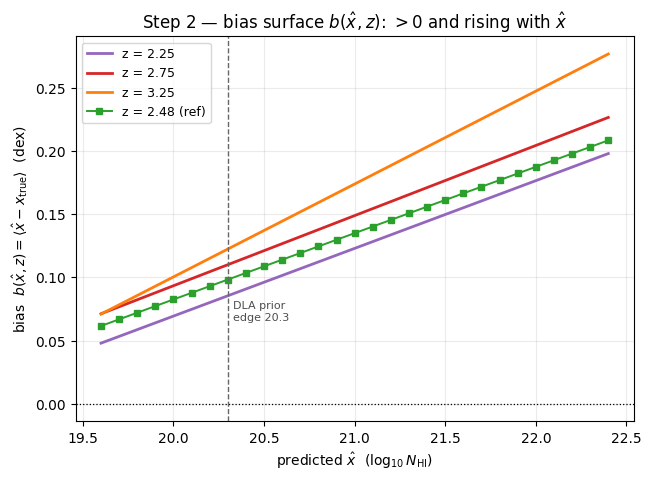

In [6]:
# Step 2: parametric bias surface b(xhat, z) at three z slices.
xs = np.arange(19.6, 22.4 + 1e-9, 0.1)
fig, ax = plt.subplots(figsize=(7.2, 5.0))
for zc, cc in zip(Z_SLICES, Z_COLS):
    ax.plot(xs, znz.b(xs, np.full_like(xs, zc)), "-", color=cc, lw=2.0,
            label=f"z = {zc:.2f}")
ax.plot(xs, znz.b(xs, np.full_like(xs, z_ref)), "s-", color="#2ca02c", ms=4,
        lw=1.4, label=f"z = {z_ref:.2f} (ref)")
ax.axhline(0.0, color="k", lw=0.9, ls=":")
ax.axvline(20.3, color="0.4", lw=1.0, ls="--")
ax.text(20.33, 0.066, "DLA prior\nedge 20.3", fontsize=8, color="0.3")
ax.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax.set_ylabel(r"bias  $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$  (dex)")
ax.set_title(r"Step 2 — bias surface $b(\hat x,z)$: $>0$ and rising with $\hat x$")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.25)

b_lo = float(znz.b(np.array([19.6]), np.array([z_ref]))[0])
b_hi = float(znz.b(np.array([22.4]), np.array([z_ref]))[0])
# ---- SELF-CHECK: b > 0 and rises with xhat ---------------------------------
assert b_lo > 0 and b_hi > b_lo, f"bias not positive+rising: {b_lo}->{b_hi}"
print(f"SELF-CHECK PASS: b(z_ref) rises {b_lo:+.4f} -> {b_hi:+.4f} dex "
      f"as x̂: 19.6 -> 22.4  (positive & monotone-up)")
plt.show()

### Step 3 — the scatter surface $\sigma(\hat x,z)$

The bias surface gives the *centre* of the response; its **width** is the second
parametric surface,

$$ \sigma(\hat x, z) \;=\; \sqrt{\,\mathrm{Var}\!\left[\hat x - x_{\rm true}\,\middle|\,\hat x, z\right]\,}, $$

fit the same way (`ZNZModel.sigma`, the `sig_coef` polynomial, clipped $>0$). It
is the dex-scale of the smear: how far a single detection's $\hat x$ typically
lands from the trend $b$.

It **shrinks toward high $\hat x$** — from $\sim0.15$ dex at the sub-DLA/LLS end
down to $\sim0.10$ dex for strong DLAs. Strong, saturated DLAs imprint a wide,
distinctive damping profile the GP measures precisely; marginal sub-DLAs are
shallow and easily confused, so their $\hat x$ scatters more. Together Steps 2–3
are the *parametric* summary of the response: a biased ($b>0$, rising) centre with
a width ($\sigma$) that narrows where the absorbers are strong.

SELF-CHECK PASS: sigma(z_ref) shrinks 0.1521 -> 0.0993 dex as x̂: 19.6 -> 22.4  (LLS wider, DLA tighter)


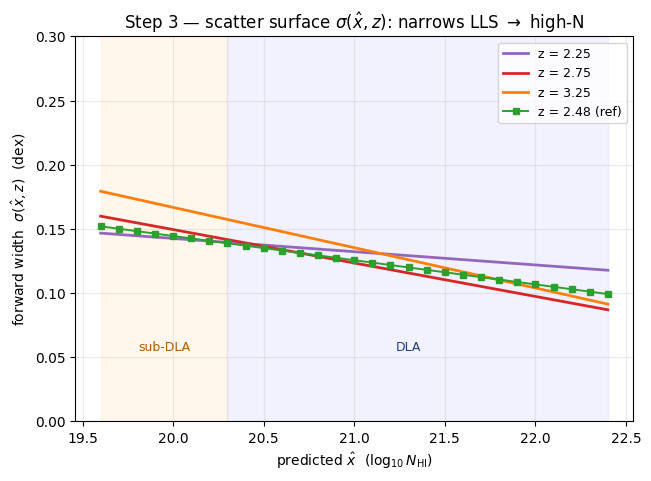

In [7]:
# Step 3: parametric scatter surface sigma(xhat, z) at three z slices.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
for zc, cc in zip(Z_SLICES, Z_COLS):
    ax.plot(xs, znz.sigma(xs, np.full_like(xs, zc)), "-", color=cc, lw=2.0,
            label=f"z = {zc:.2f}")
ax.plot(xs, znz.sigma(xs, np.full_like(xs, z_ref)), "s-", color="#2ca02c", ms=4,
        lw=1.4, label=f"z = {z_ref:.2f} (ref)")
ax.axvspan(19.6, 20.3, color="orange", alpha=0.08)
ax.axvspan(20.3, 22.4, color="blue", alpha=0.05)
ax.text(19.95, 0.055, "sub-DLA", fontsize=9, ha="center", color="#b35900")
ax.text(21.3, 0.055, "DLA", fontsize=9, ha="center", color="#1f3f7a")
ax.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax.set_ylabel(r"forward width  $\sigma(\hat x,z)$  (dex)")
ax.set_title(r"Step 3 — scatter surface $\sigma(\hat x,z)$: narrows LLS $\to$ high-N")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.25)
ax.set_ylim(0, 0.30)

s_lo = float(znz.sigma(np.array([19.6]), np.array([z_ref]))[0])
s_hi = float(znz.sigma(np.array([22.4]), np.array([z_ref]))[0])
# ---- SELF-CHECK: width shrinks toward high xhat ----------------------------
assert s_hi < s_lo, f"width does not shrink toward high N: {s_lo}->{s_hi}"
print(f"SELF-CHECK PASS: sigma(z_ref) shrinks {s_lo:.4f} -> {s_hi:.4f} dex "
      f"as x̂: 19.6 -> 22.4  (LLS wider, DLA tighter)")
plt.show()

### Step 4 — the per-cell columns: $p(\hat x\mid N)$ at fixed true-$N$ anchors

Steps 2–3 are the *parametric* picture. The headline kernel is the
**non-parametric** `EmpiricalForwardDensity`: for each $(\mathrm{SNR},z)$ cell it
stores a smoothed residual density on a shared grid, evaluated at several true-$N$
**anchors**. `emp.density(x̂, N, SNR, z)` looks up the cell and returns
$p(\hat x\mid N)=\rho(r=\hat x-N)$, interpolating linearly between anchors.

This is the heart of the construction: **each true column $N$ maps to a whole
distribution of measured $\hat x$**, not a single value. The figure draws those
distributions — the **columns** of the forward response — for a few fixed $N$ in
one representative $(\mathrm{SNR},z)$ cell. Read it as: "if the truth is $N$, the
GP reports $\hat x$ drawn from *this* curve." Two features to notice:

* each column's mean (the dot) sits **above** its true $N$ (vertical dotted line)
  — the same up-migration, now per-column; and
* the high-$N$ columns are **taller and narrower** (smaller $\sigma$, Step 3),
  the low-$N$ columns shorter and wider.

Stacking all these columns side by side is the response *matrix* (Step 5).

SELF-CHECK PASS: every forward column mean E[x̂|N] > N (up-migration):
  N=19.5  ->  E[x̂|N]-N = +0.2452 dex
  N=20.0  ->  E[x̂|N]-N = +0.0611 dex
  N=20.5  ->  E[x̂|N]-N = +0.0492 dex
  N=21.0  ->  E[x̂|N]-N = +0.0597 dex
  N=21.5  ->  E[x̂|N]-N = +0.0611 dex


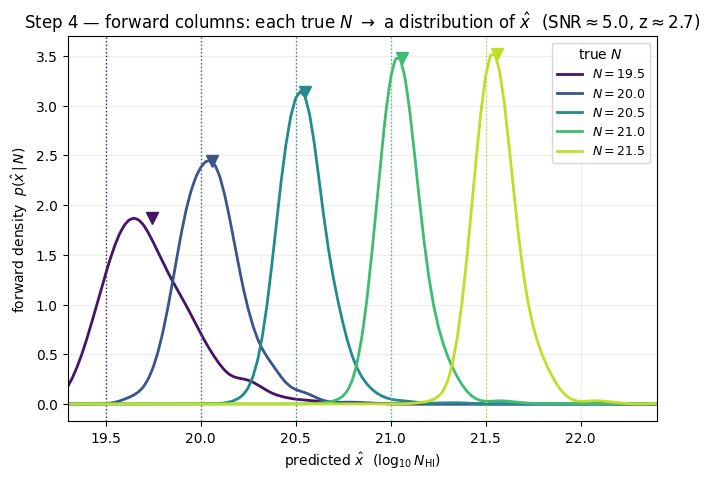

In [8]:
# Step 4: forward columns p(xhat | N) at fixed N anchors, one (SNR,z) cell.
snr_c, z_c = 5.0, 2.7                 # a representative populated cell centre
xh = np.linspace(19.3, 22.6, 400)
N_show = [19.5, 20.0, 20.5, 21.0, 21.5]
ccols = plt.cm.viridis(np.linspace(0.05, 0.9, len(N_show)))

fig, ax = plt.subplots(figsize=(7.6, 5.0))
shifts = []
for Nt, cc in zip(N_show, ccols):
    p = emp.density(xh, np.full_like(xh, Nt), snr_c, z_c)
    ax.plot(xh, p, "-", color=cc, lw=2.0, label=f"$N={Nt:.1f}$")
    Ex = float((p * xh).sum() / p.sum())
    ax.axvline(Nt, color=cc, ls=":", lw=1.0)         # true N
    ax.plot([Ex], [p.max()], "v", color=cc, ms=8)     # mean E[xhat|N]
    shifts.append(Ex - Nt)
ax.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax.set_ylabel(r"forward density  $p(\hat x\,|\,N)$")
ax.set_title(r"Step 4 — forward columns: each true $N$ $\to$ a distribution of "
             r"$\hat x$  (SNR$\approx$%.1f, z$\approx$%.1f)" % (snr_c, z_c))
ax.legend(fontsize=9, title="true $N$", loc="upper right")
ax.set_xlim(19.3, 22.4)
ax.grid(alpha=0.22)

# ---- SELF-CHECK: every column's mean sits above its true N (up-migration) ---
shifts = np.array(shifts)
assert np.all(shifts > 0), f"a forward column centres below its true N: {shifts}"
print("SELF-CHECK PASS: every forward column mean E[x̂|N] > N (up-migration):")
for Nt, s in zip(N_show, shifts):
    print(f"  N={Nt:.1f}  ->  E[x̂|N]-N = {s:+.4f} dex")
plt.show()

### Step 5 — assemble the forward response matrix $p(\hat x\mid N)$

Now stack every column from Step 4, sweeping the true-$N$ axis continuously and
**column-normalising over $\hat x$** at fixed $N$ (the forward convention,
$\int p\,d\hat x=1$). The result is the 2-D **forward response matrix**

$$ p(\hat x \mid N_{\rm true}), $$

shown as an image with $N_{\rm true}$ on the horizontal axis and the measured
$\hat x$ on the vertical. To be population-representative we equal-weight-average
the empirical density over all populated $(\mathrm{SNR},z)$ cells, each evaluated
at its cell centre — exactly the construction in `plot_kernel.main`.

The overlaid cyan curve is the **forward centering** $E[\hat x\mid N]$; it lies
**above** the white identity line — the same up-migration, now as a property of
the whole matrix. **This matrix is the object the HBI deconvolves**: given the
catalog of measured $\hat x_i$, invert this $p(\hat x\mid N)$ to recover the true
$f(N)$.

SELF-CHECK PASS: mean forward up-migration over DLA range (N>=20.3) b = +0.0458 dex  > 0
  E[x̂|N]-N range: +0.0172 .. +0.2509 dex


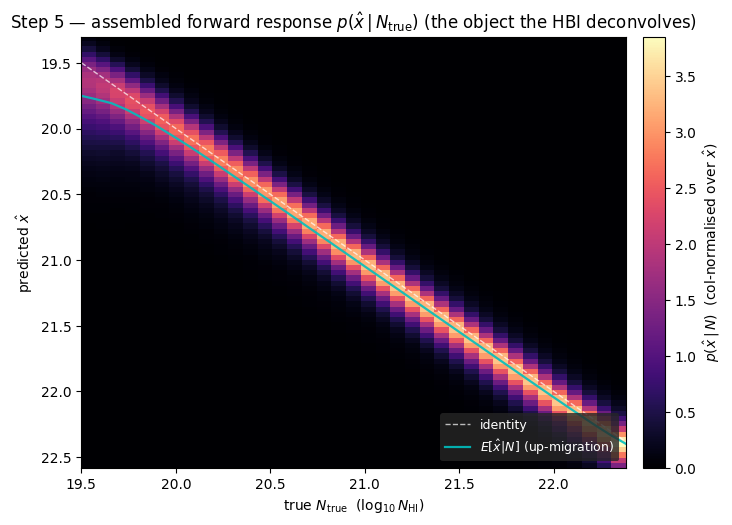

In [9]:
# Step 5: assemble the population-representative forward response matrix.
Ntrue = np.arange(19.5, 22.4 + 1e-9, 0.08)
xhat  = np.arange(19.3, 22.6 + 1e-9, 0.04)
P = np.zeros((len(xhat), len(Ntrue)))
ncell = 0
for sc in SNR_CEN:
    for zc in Z_CEN:
        for j, Nt in enumerate(Ntrue):
            P[:, j] += emp.density(xhat, np.full_like(xhat, Nt), sc, zc)
        ncell += 1
P /= ncell

# column-normalise p(x̂|N) over x̂ at fixed N (the forward convention)
col = _trapz(P, xhat, axis=0)
Pn = P / np.where(col[None, :] > 1e-9, col[None, :], 1.0)
# forward centering E[x̂|N] (rises ABOVE identity = up-migration)
Exhat = (Pn * xhat[:, None]).sum(0) / np.clip(Pn.sum(0), 1e-12, None)
up_migration = Exhat - Ntrue

# ---- SELF-CHECK: forward centering above identity over the DLA range --------
dla = Ntrue >= 20.3
mean_up_dla = float(up_migration[dla].mean())
assert mean_up_dla > 0.0, f"forward centering NOT above identity (b={mean_up_dla})"
print(f"SELF-CHECK PASS: mean forward up-migration over DLA range (N>=20.3) "
      f"b = {mean_up_dla:+.4f} dex  > 0")
print(f"  E[x̂|N]-N range: {up_migration.min():+.4f} .. {up_migration.max():+.4f} dex")

fig, ax = plt.subplots(figsize=(7.6, 5.6))
extent = [Ntrue[0], Ntrue[-1], xhat[-1], xhat[0]]
im = ax.imshow(Pn, aspect="auto", extent=extent, cmap="magma",
               interpolation="nearest")
ax.plot([19.5, 22.4], [19.5, 22.4], "w--", lw=1.0, alpha=0.7, label="identity")
ax.plot(Ntrue, Exhat, "c-", lw=1.6, alpha=0.9,
        label=r"$E[\hat x|N]$ (up-migration)")
ax.set_xlabel(r"true $N_{\rm true}$  ($\log_{10} N_{\rm HI}$)")
ax.set_ylabel(r"predicted $\hat x$")
ax.set_ylim(extent[2], extent[3])
ax.set_xlim(Ntrue[0], Ntrue[-1])
ax.set_title(r"Step 5 — assembled forward response $p(\hat x\,|\,N_{\rm true})$ "
             r"(the object the HBI deconvolves)")
ax.legend(fontsize=9, loc="lower right", labelcolor="w",
          facecolor="0.15", edgecolor="none")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label(r"$p(\hat x\,|\,N)$  (col-normalised over $\hat x$)")
plt.show()

### Step 6 — the forward normalisation signature

The fact that defines the forward response is **which axis it normalises over**.
The forward density is normalised **over $\hat x$** at fixed $N$,

$$ \int p(\hat x\mid N)\,d\hat x = 1, $$

— this is the genuine, clean, load-bearing **forward signature**: at *every* true
$N$ the predicted-$\hat x$ density integrates to exactly 1. That is the assertion
the self-check below makes.

The complementary contraction, $\int p(\hat x\mid N)\,d(\log N)$ at fixed $\hat x$,
is **not** a clean discriminant: it is **$N$-dependent**, ranging $\sim$0.5–1.24
across $\hat x$, and near the *interior* (e.g. $\hat x\approx 21$) it happens to sit
$\approx 1$ — exactly where a genuine posterior would also give $\approx 1$. So
"$\int p\,d(\log N)\neq 1$" is **not** a reliable forward-vs-posterior test; it only
departs from 1 noticeably near the **low-$N$ edge** ($\hat x\approx 19.8$), where the
kernel's $N$-dependent width/skew makes the over-$N$ contraction fall short. We show
it below as an **illustrative observation** (not a self-check): a GP *posterior*
$\kappa(N\mid\hat x)$ would by construction satisfy $\int\kappa\,d(\log N)=1$ at all
$\hat x$, whereas this forward density does not — but the *clean* signature, and the
one we assert, is the over-$\hat x$ normalisation. The figure draws both contractions
side by side.

(1) FORWARD : ∫ p(x̂|N=21.0) dx̂            = 1.0000   (target 1.0  -> x̂-normalised: THE forward signature)
(2) over N  : ∫ p(x̂=19.8|N) d(logN)       = 1.1924   (illustrative; departs from 1 at the low-N edge)
    over N  : ∫ p(x̂=21.0|N) d(logN)       = 0.9811   (in the INTERIOR it sits ~1 -> NOT a discriminant there)

SELF-CHECK PASS:
  |∫p dx̂ - 1|     = 0.0000  < 0.05  (x̂-normalised  -> forward likelihood)
  (illustrative) ∫p d(logN) = 1.1924 at x̂=19.8 (edge) vs 0.9811 at x̂=21 (interior, ~1) — N-dependent, not the discriminant


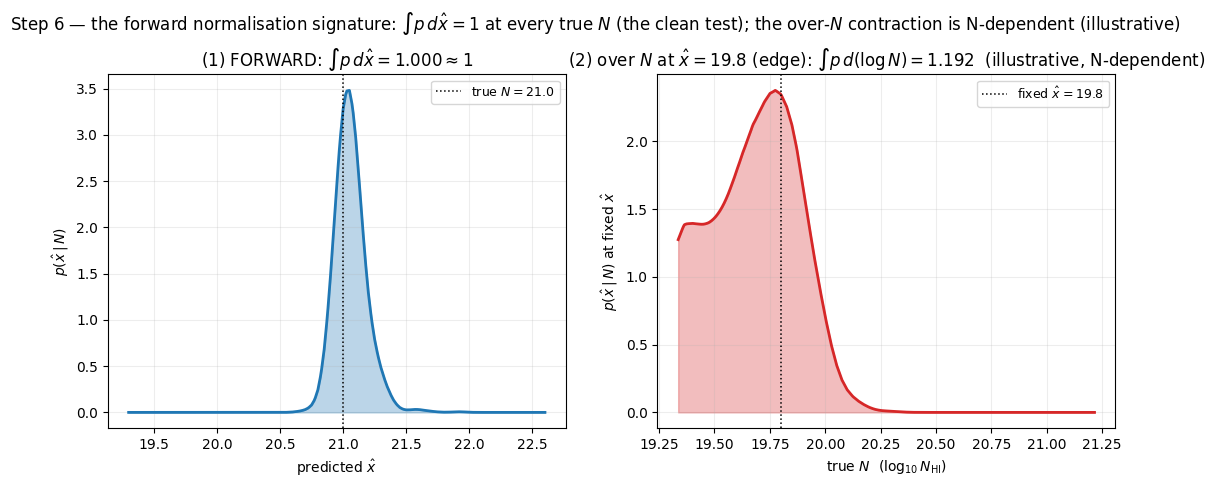

In [10]:
# Step 6: the normalisation discriminant on the real kernel.
# INTEGRAL-to-INTEGRAL: both sides carry their measure (d x̂ vs d(logN)), so we are
# NOT comparing a measure-weighted integral to a bare grid sum (a bare sum_N p on a
# 0.1-dex grid is ~10 for a forward density AND for a genuine posterior — a
# 1/d(logN) grid artifact, not a discriminant).
snr_d, z_d = 5.0, 2.7

# (1) FORWARD normalisation: integrate p(x̂|N) over x̂ at a fixed true N -> == 1
N_fixed = 21.0
xhat_grid = np.linspace(19.3, 22.6, 331)
p_over_xhat = emp.density(xhat_grid, np.full_like(xhat_grid, N_fixed), snr_d, z_d)
integral_over_xhat = float(_trapz(p_over_xhat, xhat_grid))

# (2) ILLUSTRATIVE (not a self-check): the over-N contraction at a fixed x̂.
# This is N-DEPENDENT, not a clean discriminant: in the interior (x̂~21) it sits
# ~1, exactly where a posterior would too. It departs from 1 noticeably only near
# the low-N EDGE (x̂~19.8), from the kernel's N-dependent width/skew. We pick
# x̂=19.8 to SHOW that edge departure, but we do NOT assert on it.
xhat_fixed = 19.8
N_grid6 = np.linspace(float(emp.N_anchors.min()), float(emp.N_anchors.max()), 400)
p_over_N = emp.density(np.full_like(N_grid6, xhat_fixed), N_grid6, snr_d, z_d)
integral_over_N = float(_trapz(p_over_N, N_grid6))
# corroborate the N-dependence: in the interior the over-N integral is ~1 (so it is
# NOT a discriminant there — a posterior would give ~1 too).
xhat_interior = 21.0
p_over_N_int = emp.density(np.full_like(N_grid6, xhat_interior), N_grid6, snr_d, z_d)
integral_over_N_int = float(_trapz(p_over_N_int, N_grid6))

print(f"(1) FORWARD : ∫ p(x̂|N={N_fixed}) dx̂            = "
      f"{integral_over_xhat:.4f}   (target 1.0  -> x̂-normalised: THE forward signature)")
print(f"(2) over N  : ∫ p(x̂={xhat_fixed}|N) d(logN)       = "
      f"{integral_over_N:.4f}   (illustrative; departs from 1 at the low-N edge)")
print(f"    over N  : ∫ p(x̂={xhat_interior}|N) d(logN)       = "
      f"{integral_over_N_int:.4f}   (in the INTERIOR it sits ~1 -> NOT a discriminant there)")

# ---- SELF-CHECK: the forward signature is the over-x̂ normalisation = 1 ------
assert abs(integral_over_xhat - 1) < 0.05, \
    f"forward NOT x̂-normalised: ∫p dx̂={integral_over_xhat}"
print()
print("SELF-CHECK PASS:")
print(f"  |∫p dx̂ - 1|     = {abs(integral_over_xhat - 1):.4f}  < 0.05  "
      f"(x̂-normalised  -> forward likelihood)")
print(f"  (illustrative) ∫p d(logN) = {integral_over_N:.4f} at x̂=19.8 (edge) vs "
      f"{integral_over_N_int:.4f} at x̂=21 (interior, ~1) — N-dependent, not the discriminant")

# figure: the two contractions side by side
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.fill_between(xhat_grid, 0, p_over_xhat, color="#1f77b4", alpha=0.30)
axA.plot(xhat_grid, p_over_xhat, color="#1f77b4", lw=2.0)
axA.axvline(N_fixed, color="k", ls=":", lw=1.1, label=f"true $N={N_fixed}$")
axA.set_xlabel(r"predicted $\hat x$")
axA.set_ylabel(r"$p(\hat x\,|\,N)$")
axA.set_title(r"(1) FORWARD: $\int p\,d\hat x = %.3f \approx 1$" % integral_over_xhat)
axA.legend(fontsize=9)
axA.grid(alpha=0.22)

axB.fill_between(N_grid6, 0, p_over_N, color="#d62728", alpha=0.30)
axB.plot(N_grid6, p_over_N, color="#d62728", lw=2.0)
axB.axvline(xhat_fixed, color="k", ls=":", lw=1.1,
            label=f"fixed $\\hat x={xhat_fixed}$")
axB.set_xlabel(r"true $N$  ($\log_{10} N_{\rm HI}$)")
axB.set_ylabel(r"$p(\hat x\,|\,N)$ at fixed $\hat x$")
axB.set_title(r"(2) over $N$ at $\hat x=19.8$ (edge): $\int p\,d(\log N) = %.3f$"
              "  (illustrative, N-dependent)" % integral_over_N)
axB.legend(fontsize=9)
axB.grid(alpha=0.22)
fig.suptitle("Step 6 — the forward normalisation signature: "
             r"$\int p\,d\hat x=1$ at every true $N$ (the clean test); "
             "the over-$N$ contraction is N-dependent (illustrative)", y=1.02)
plt.show()

---
## The assembled kernel figure (canonical four-panel summary)

Having built the response step by step, here is the canonical four-panel summary
(adapted from the generator `scripts/plot_kernel.py`), which packs Steps 2, 3 and
5 into one publication figure:

* **(a) forward centering** $E[\hat x\mid N_{\rm true}]$ vs $N_{\rm true}$ (Step 5
  curve), with the identity line — it sits **above** identity → **up-migration**.
* **(b) bias surface** $b(\hat x,z)$ (Step 2) — rising with $\hat x$.
* **(c) forward width** $\sigma(\hat x,z)$ (Step 3) — shrinking LLS → high-N.
* **(d) forward response matrix** $p(\hat x\mid N_{\rm true})$ (Step 5) — the
  object the HBI A-build deconvolves; the cyan curve is the panel-(a) centering.

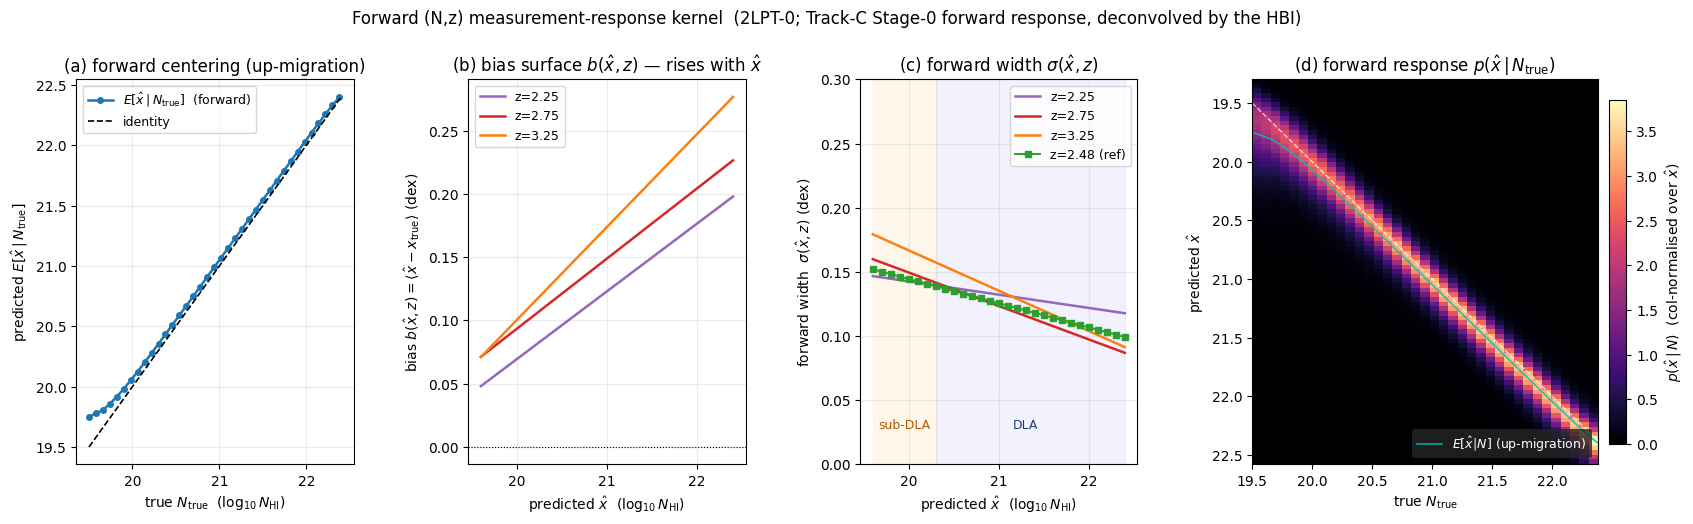

In [11]:
# Canonical 4-panel kernel figure (reuses Step-2/3/5 arrays computed above).
sig_ref_curve = znz.sigma(xs, np.full_like(xs, z_ref))

fig = plt.figure(figsize=(20, 5.0))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.35], wspace=0.38)

# (a) forward centering E[x̂|N] vs N
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(Ntrue, Exhat, "o-", color="#1f77b4", ms=4, lw=1.8,
         label=r"$E[\hat x\,|\,N_{\rm true}]$  (forward)")
ax0.plot([19.5, 22.4], [19.5, 22.4], "k--", lw=1.2, label="identity")
ax0.set_xlabel(r"true $N_{\rm true}$  ($\log_{10} N_{\rm HI}$)")
ax0.set_ylabel(r"predicted $E[\hat x\,|\,N_{\rm true}]$")
ax0.set_title("(a) forward centering (up-migration)")
ax0.legend(loc="upper left", fontsize=9)
ax0.grid(alpha=0.25)

# (b) bias surface b(x̂,z), rising with x̂
ax1 = fig.add_subplot(gs[0, 1])
for zc, cc in zip(Z_SLICES, Z_COLS):
    ax1.plot(xs, znz.b(xs, np.full_like(xs, zc)), "-", color=cc, lw=1.8,
             label=f"z={zc:.2f}")
ax1.axhline(0, color="k", lw=0.8, ls=":")
ax1.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax1.set_ylabel(r"bias $b(\hat x,z)=\langle\hat x-x_{\rm true}\rangle$ (dex)")
ax1.set_title(r"(b) bias surface $b(\hat x,z)$ — rises with $\hat x$")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.25)

# (c) forward width sigma(x̂,z)
ax2 = fig.add_subplot(gs[0, 2])
for zc, cc in zip(Z_SLICES, Z_COLS):
    ax2.plot(xs, znz.sigma(xs, np.full_like(xs, zc)), "-", color=cc, lw=1.8,
             label=f"z={zc:.2f}")
ax2.plot(xs, sig_ref_curve, "s-", color="#2ca02c", ms=4, lw=1.4,
         label=f"z={z_ref:.2f} (ref)")
ax2.axvspan(19.6, 20.3, color="orange", alpha=0.08)
ax2.axvspan(20.3, 22.4, color="blue", alpha=0.05)
ax2.text(19.95, 0.028, "sub-DLA", fontsize=9, ha="center", color="#b35900")
ax2.text(21.3, 0.028, "DLA", fontsize=9, ha="center", color="#1f3f7a")
ax2.set_xlabel(r"predicted $\hat x$  ($\log_{10} N_{\rm HI}$)")
ax2.set_ylabel(r"forward width  $\sigma(\hat x,z)$ (dex)")
ax2.set_title(r"(c) forward width $\sigma(\hat x,z)$")
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(alpha=0.25)
ax2.set_ylim(0, 0.30)

# (d) imshow of the forward response matrix p(x̂|N)
ax3 = fig.add_subplot(gs[0, 3])
im = ax3.imshow(Pn, aspect="auto", extent=extent, cmap="magma",
                interpolation="nearest")
ax3.plot([19.5, 22.4], [19.5, 22.4], "w--", lw=1.0, alpha=0.7)
ax3.plot(Ntrue, Exhat, "c-", lw=1.2, alpha=0.85,
         label=r"$E[\hat x|N]$ (up-migration)")
ax3.set_xlabel(r"true $N_{\rm true}$")
ax3.set_ylabel(r"predicted $\hat x$")
ax3.set_ylim(extent[2], extent[3])
ax3.set_xlim(Ntrue[0], Ntrue[-1])
ax3.set_title(r"(d) forward response $p(\hat x\,|\,N_{\rm true})$")
ax3.legend(fontsize=9, loc="lower right", labelcolor="w",
           facecolor="0.15", edgecolor="none")
cb = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.03)
cb.set_label(r"$p(\hat x\,|\,N)$  (col-normalised over $\hat x$)")

fig.suptitle("Forward (N,z) measurement-response kernel  (2LPT-0; Track-C "
             "Stage-0 forward response, deconvolved by the HBI)", y=1.02)
plt.show()

## Reading the figure

* **Panel (a)/(d) — up-migration.** The forward centering $E[\hat x\mid N]$ sits
  *above* the identity line: a true column is, on average, *over-reported*. This
  is Eddington bias against the steep $f(N)$ — there are simply more low-$N$
  absorbers to scatter up than high-$N$ ones to scatter down. The cyan curve in
  (d) is this same centering on the response matrix.
* **Panel (b) — the prior edge.** The conditional bias $b(\hat x,z)>0$ and
  **rises with $\hat x$**: detections reported nearer the DLA prior edge
  ($\log N_{\rm HI}\approx20.3$) carry the most up-migration, because that is
  where sub-DLAs pile up after scattering across the edge. It also rises with
  $z$ (denser forest → more blending pushes absorbers toward the edge).
* **Panel (c) — the width narrows.** $\sigma(\hat x,z)$ shrinks toward high
  $\hat x$ — strong DLAs are measured more precisely than marginal ones.

**Why deconvolving this fixes $\Omega_{\rm HI}$.** The high-$N$ tail of the
*measured* CDDF is inflated by up-migrated sub-DLAs (the population that should
sit below $20.3$ leaks above it). Inverting the forward response — which keeps
that up-migration explicit and prior-free — pushes that leaked mass back down,
**re-steepening** the true high-$N$ tail. Because $\Omega_{\rm HI}\propto\int N
f(N)\,dN$ is dominated by the high-$N$ end, getting the tail slope right is what
brings $\Omega$ back to truth (this is the over-recovery the headline run fixes;
NB4 quantifies it on the mock).

## How a single design entry $A_{i,jN,kz}$ is built

The estimator turns this kernel into a sparse design tensor that maps the
population $f$-coefficients to each detection's expected contribution. For
detection $i$, true-$N$ segment $jN$, and fine $z$-bin $kz$, the forward A-build
deposits (schematically)

$$ A_{i,\,jN,\,kz} \;=\; \underbrace{\Big(\textstyle\int_{\rm seg}(N\ln 10)\,dx\Big)}_{\text{segment width }dN_{\rm seg}}
\;\cdot\; \underbrace{p(\hat x_i \mid N_{\rm seg},\,\mathrm{SNR}_i,\,z_i)}_{\text{forward density at this detection's }\hat x_i}
\;\cdot\; \underbrace{(\text{z-mass of } \hat z_i \text{ in bin } kz)}_{\text{erf-mass}\times\,dX/dz}. $$

The middle factor $p(\hat x_i\mid N_{\rm seg},\mathrm{SNR}_i,z_i)$ is exactly the
forward response built in Steps 1–5 — evaluated at *this* detection's measured
$\hat x_i$, SNR$_i$ and $z_i$, for each candidate true-$N$ segment.

The **critical** point — and the whole reason the forward fix works — is that
$p(\hat x_i\mid N)$ is a **density** in $\hat x$, already per-unit-$\hat x$. It is
therefore **not** divided by the segment width $\Delta x_{\rm seg}$ the way a
per-bin *mass* (a posterior $\kappa$, or a Gaussian CDF mass) would be. Applying
that division here would *double-divide* — the exact mass-vs-density category
error this notebook is about. The forward build multiplies by $dN_{\rm seg}$ only
("density, not mass").

Production code: see `build_A_ib` (the dispatch) and `_build_A_ib_forward` (the
forward branch) in `CDDF_analysis/hbi/cddf_catalog_hbi.py`; the kappa branch
`_build_A_ib_kappa2d` is the legacy posterior path it replaces.

## Honesty note: which response the estimator actually uses

The config switch is `cfg.resp_kind`:

* **`"kappa"` (the dataclass DEFAULT)** — build $A$ from the cached **GP-posterior**
  $\kappa(N\mid\hat x)$, byte-identical to the legacy behaviour. This is the
  posterior-warp path, and per the crux above it **cannot** deconvolve the
  up-migration; it is kept only for backward compatibility and is **gated off**
  for the science result.
* **`"forward"` (the headline)** — build $A$ from the **forward** response
  $p(\hat x\mid N,\mathrm{SNR},z)$ shown here (with `resp_family="empirical"` for
  the non-parametric kernel). This is the deconvolution that re-steepens the
  high-$N$ tail and corrects $\Omega_{\rm HI}$.

So the object drawn in this notebook *is* the one the headline estimator
deconvolves — the legacy posterior default is the contrast, not the result.

> **Next — NB3.** Now that we have the forward kernel, NB3 opens up the
> **likelihood** built on top of it, the **MAP solve** for $f(N,z)$, and the
> correlated **Monte-Carlo band** — the full deconvolution machine running on
> the real 2LPT-0 kernel.